In [2]:
from updated_tools import *

PRODUCT = "HYDROGEL_PACK"
LOW = 0e6
HIGH = 3e6
WINDOW = 30

df = extract_data(3, 120000)
df = df[df["product"] == PRODUCT]
df = df[(df['bid_price_1'].notna()) & (df['ask_price_1'].notna())]
df = df[(df["timestamp"] >= LOW) & (df["timestamp"] <= HIGH)]
# plot_mid_price(df)
# plot_autocorrelation(df, max_lag = 1000)

print(df["mid_price"].mean())
print(df["mid_price"].std())

# df["rolling_mid"] = df["mid_price"].rolling(window = WINDOW).mean()
# df["rolling_diff"] = df["rolling_mid"] - df["mid_price"]
# plot_against_timestamp(df, ["rolling_diff"])

9990.806866666666
31.935213763359915


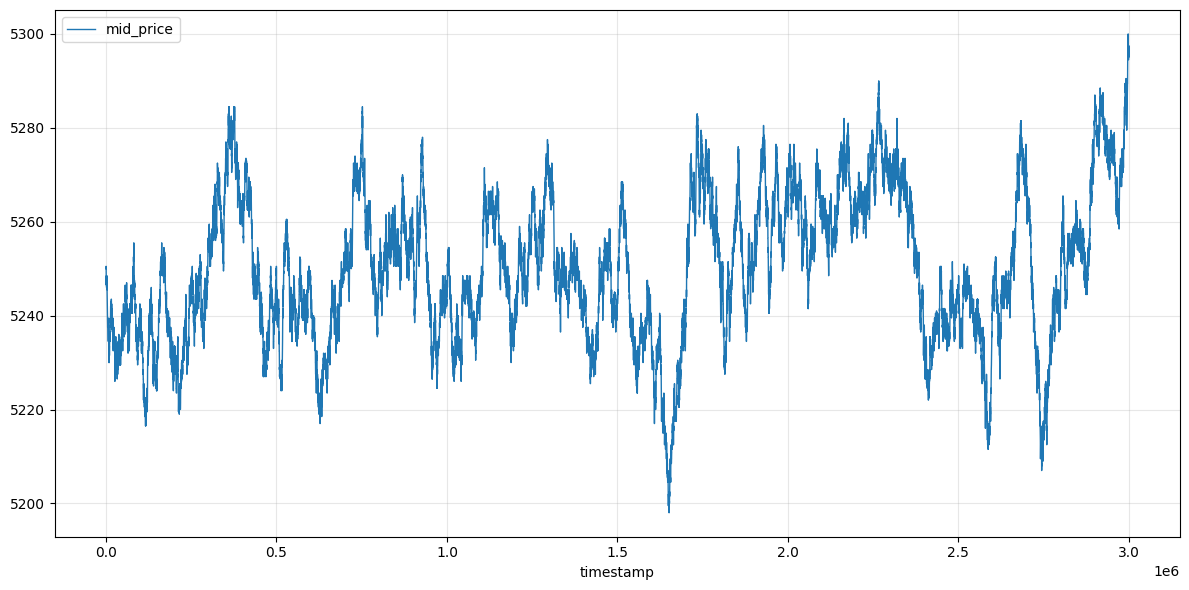

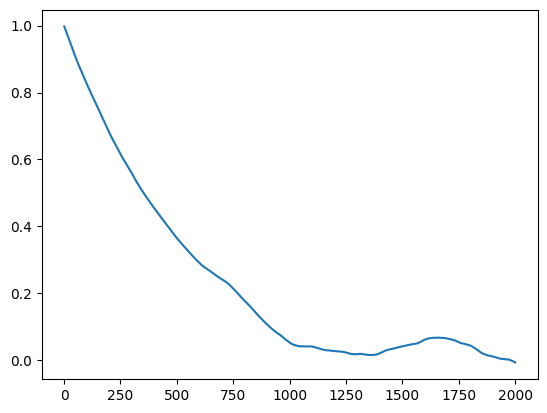

In [7]:
PRODUCT = "VELVETFRUIT_EXTRACT"
LOW = 0e6
HIGH = 3e6

df = extract_data(3, 120000)
df = df[df["product"] == PRODUCT]
df = df[(df['bid_price_1'].notna()) & (df['ask_price_1'].notna())]
df = df[(df["timestamp"] >= LOW) & (df["timestamp"] <= HIGH)]
plot_mid_price(df)
plot_autocorrelation(df, 2000)

# df["best_diff"] = df["best_ask"] - df["best_bid"]
# print(df["best_diff"].mean())
# plot_against_timestamp(df, ["best_diff"])

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import log, sqrt

from math import floor, ceil, log, sqrt, exp
from statistics import NormalDist

class BlackScholes:
    @staticmethod
    def black_scholes_call(spot, strike, time_to_expiry, volatility):
        d1 = (log(spot) - log(strike) + (0.5 * volatility * volatility) * time_to_expiry) / (volatility * sqrt(time_to_expiry))
        d2 = d1 - volatility * sqrt(time_to_expiry)
        call_price = spot * NormalDist().cdf(d1) - strike * NormalDist().cdf(d2)
        return call_price

    @staticmethod
    def black_scholes_put(spot, strike, time_to_expiry, volatility):
        d1 = (log(spot) - log(strike) + (0.5 * volatility * volatility) * time_to_expiry) / (volatility * sqrt(time_to_expiry))
        d2 = d1 - volatility * sqrt(time_to_expiry)
        put_price = strike * NormalDist().cdf(-d2) - spot * NormalDist().cdf(-d1)
        return put_price

    @staticmethod
    def delta_call(spot, strike, time_to_expiry, volatility):
        d1 = (log(spot) - log(strike) + (0.5 * volatility * volatility) * time_to_expiry) / (volatility * sqrt(time_to_expiry))
        return NormalDist().cdf(d1)
    
    @staticmethod
    def delta_put(spot, strike, time_to_expiry, volatility):
        return BlackScholes.delta_call(spot, strike, time_to_expiry, volatility) - 1

    @staticmethod
    def gamma(spot, strike, time_to_expiry, volatility):
        d1 = (log(spot) - log(strike) + (0.5 * volatility * volatility) * time_to_expiry) / (volatility * sqrt(time_to_expiry))
        return NormalDist().pdf(d1) / (spot * volatility * sqrt(time_to_expiry))

    @staticmethod
    def vega(spot, strike, time_to_expiry, volatility):
        d1 = (log(spot) - log(strike) + (0.5 * volatility * volatility) * time_to_expiry) / (volatility * sqrt(time_to_expiry))
        return NormalDist().pdf(d1) * (spot * sqrt(time_to_expiry)) / 100

    @staticmethod
    def implied_volatility_call(
        call_price, spot, strike, time_to_expiry, max_iterations=200, tolerance=1e-10
    ):
        low_vol = 0.0001
        high_vol = 2.0
        volatility = (low_vol + high_vol) / 2.0
        for _ in range(max_iterations):
            estimated_price = BlackScholes.black_scholes_call(spot, strike, time_to_expiry, volatility)
            diff = estimated_price - call_price
            if abs(diff) < tolerance:
                break
            elif diff > 0:
                high_vol = volatility
            else:
                low_vol = volatility
            volatility = (low_vol + high_vol) / 2.0
        return volatility
    
    @staticmethod
    def implied_volatility_put(
        put_price, spot, strike, time_to_expiry, max_iterations=200, tolerance=1e-10
    ):
        low_vol = 0.0001
        high_vol = 2.0
        volatility = (low_vol + high_vol) / 2.0
        for _ in range(max_iterations):
            estimated_price = BlackScholes.black_scholes_put(spot, strike, time_to_expiry, volatility)
            diff = estimated_price - put_price
            if abs(diff) < tolerance:
                break
            elif diff > 0:
                high_vol = volatility
            else:
                low_vol = volatility
            volatility = (low_vol + high_vol) / 2.0
        return volatility

    @staticmethod
    def moneyness(spot, strike, time_to_expiry):
        return log(spot / strike) / sqrt(time_to_expiry)

# =========================
# MAIN FUNCTION
# =========================
def option_scalping_analysis(df: pd.DataFrame):
    STRIKES = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]

    # ---- TIME TO EXPIRY (your formula) ----
    df = df.copy()
    df["time_to_expiry"] = 8 / 365 - (df["timestamp"] / 365e6)

    # split underlying
    spot_df = df[df["product"] == "VELVETFRUIT_EXTRACT"][
        ["timestamp", "mid_price"]
    ].rename(columns={"mid_price": "spot"})

    results = []

    # ---- iterate options ----
    for strike in STRIKES:
        opt_df = df[df["product"] == f"VEV_{strike}"].copy()

        merged = opt_df.merge(spot_df, on="timestamp", how="inner")

        # compute IV + moneyness
        for _, row in merged.iterrows():
            spot = row["spot"]
            price = row["mid_price"]
            t = row["time_to_expiry"]

            # skip invalid states
            if t <= 0 or spot <= 0:
                continue

            iv = BlackScholes.implied_volatility_call(price, spot, strike, t)
            m = BlackScholes.moneyness(spot, strike, t)

            results.append((m, iv))

    # convert to arrays
    results = np.array(results)

    # filter out weird data; line is (0.5, 0.15) to (2, 0.4)
    # m = 0.25/1.5 = 1/6; y >= 1/6 * (x - 2) + 0.4
    results = results[results[:, 1] >= 1/6 * (results[:, 0]) + 0.4]
    x = results[:, 0]
    y = results[:, 1]    

    # ---- plot IV points ----
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, s=10)

    # ---- fit parabola ----
    a, b, c = np.polyfit(x, y, 2)

    x_fit = np.linspace(np.min(x), np.max(x), 200)
    y_fit = a * x_fit**2 + b * x_fit + c

    plt.plot(x_fit, y_fit)

    plt.xlabel("Moneyness")
    plt.ylabel("Implied Volatility")
    plt.title("IV Smile Fit")
    plt.show()

    print("Parabola coefficients (a, b, c):", (a, b, c))

    return a, b, c

df = extract_data(3, 120000)
option_scalping_analysis(df)

KeyboardInterrupt: 

In [ ]:
from __future__ import annotations

import subprocess
import tempfile
from pathlib import Path

BASE_FILE = Path("C:\\Users\\ishaa\\Downloads\\IMC-Prosperity-4\\algo\\R3_ig copy 2.py")

Z_VALUES = [1, 1.5, 2, 2.5, 3]

LINE_Z = 673
LINE_STRIKE = 769


def run_backtest(file_path: Path) -> int:
    cmd = [
        "py",
        "-3.12",
        "-m",
        "prosperity4bt",
        str(file_path),
        "3",
        "--no-out",
    ]

    proc = subprocess.run(cmd, capture_output=True, text=True)

    if proc.returncode != 0:
        raise RuntimeError(
            f"Backtest failed\nSTDOUT:\n{proc.stdout}\nSTDERR:\n{proc.stderr}"
        )

    lines = [l for l in proc.stdout.splitlines() if l.strip()]
    final_line = lines[-1]

    token = final_line.split()[-1].replace(",", "")
    return int(token)


def gridsearch_single_option(strike: int):
    """
    Gridsearch z-threshold for a single strike by modifying:
    - line 673: RollingZ
    - line 769: strike loop
    """

    if not BASE_FILE.exists():
        raise FileNotFoundError(f"Base file not found: {BASE_FILE}")

    original_lines = BASE_FILE.read_text(encoding="utf-8").splitlines(keepends=True)

    results = []

    for z in Z_VALUES:
        modified = original_lines.copy()

        # ---- Replace RollingZ line ----
        modified[LINE_Z - 1] = f"        self.theos = RollingZ({z}, 1000)\n"

        # ---- Replace strike loop line ----
        modified[LINE_STRIKE - 1] = f"            for st in [{strike}]:\n"

        with tempfile.TemporaryDirectory() as tmpdir:
            tmp_path = Path(tmpdir) / BASE_FILE.name
            tmp_path.write_text("".join(modified), encoding="utf-8")

            try:
                profit = run_backtest(tmp_path)
            except Exception as e:
                print(f"Failed for strike={strike}, z={z}: {e}")
                continue

        results.append((z, profit))
        print(f"Strike {strike} | z={z} -> profit={profit}")

    # sort best → worst
    results.sort(key=lambda x: x[1], reverse=True)

    print(f"\nTop results for strike {strike}:")
    for z, profit in results:
        print(f"z={z}, profit={profit}")

    return results


# Optional helper to run all strikes
def run_all_strikes():
    STRIKES = [4000, 4500, 5000, 5100, 5400, 5500, 6000, 6500]

    all_results = {}

    for strike in STRIKES:
        print(f"\n===== Running strike {strike} =====")
        res = gridsearch_single_option(strike)
        all_results[strike] = res

    return all_results

run_all_strikes()


===== Running strike 4000 =====
Strike 4000 | z=1 -> profit=9097
Strike 4000 | z=1.5 -> profit=7446
Strike 4000 | z=2 -> profit=4062
Strike 4000 | z=2.5 -> profit=2090
Strike 4000 | z=3 -> profit=544

Top results for strike 4000:
z=1, profit=9097
z=1.5, profit=7446
z=2, profit=4062
z=2.5, profit=2090
z=3, profit=544

===== Running strike 4500 =====
Strike 4500 | z=1 -> profit=7836
Strike 4500 | z=1.5 -> profit=5800
Strike 4500 | z=2 -> profit=3030
Strike 4500 | z=2.5 -> profit=1475
Strike 4500 | z=3 -> profit=438

Top results for strike 4500:
z=1, profit=7836
z=1.5, profit=5800
z=2, profit=3030
z=2.5, profit=1475
z=3, profit=438

===== Running strike 5000 =====
Strike 5000 | z=1 -> profit=13684
Strike 5000 | z=1.5 -> profit=15420
Strike 5000 | z=2 -> profit=14271
Strike 5000 | z=2.5 -> profit=5482
Strike 5000 | z=3 -> profit=412

Top results for strike 5000:
z=1.5, profit=15420
z=2, profit=14271
z=1, profit=13684
z=2.5, profit=5482
z=3, profit=412

===== Running strike 5100 =====
Stri

{4000: [(1, 9097), (1.5, 7446), (2, 4062), (2.5, 2090), (3, 544)],
 4500: [(1, 7836), (1.5, 5800), (2, 3030), (2.5, 1475), (3, 438)],
 5000: [(1.5, 15420), (2, 14271), (1, 13684), (2.5, 5482), (3, 412)],
 5100: [(3, 18207), (2.5, 14933), (2, 11026), (1.5, 10724), (1, 9870)],
 5400: [(3, 4394), (2.5, 4313), (1.5, 3443), (2, 3235), (1, 3091)],
 5500: [(3, 1877), (2.5, 1212), (1.5, 955), (2, 839), (1, 679)],
 6000: [(1, 218), (1.5, 120), (2, 52), (2.5, 8), (3, 2)],
 6500: [(1, 77), (1.5, 38), (2, 12), (2.5, 1), (3, 0)]}